In [ ]:
from typing import Self

import pydantic

In [ ]:
import marimo as mo

In [ ]:
import os
from pathlib import Path
from pprint import pprint
import datetime
import random
import dotenv
import pandas
import altair
from ortools.sat.python import cp_model
import amplify_sched
import didppy

# ジョブショップスケジューリング問題

$J || C_{\max}$ と書く.

- ジョブ $J_1, \dots, J_n$
- ジョブ $J_j$ に属するオペレーション $O_{1j}, \dots, O_{m_jj}$. この順で処理される.
- 機械 $M_1, \dots, M_m$
- オペレーション $O_{ij}$ は機械 $\mu_{ij}$ で作業時間 $p_{ij}$ かけて処理する.
- オペレーションは中断できない
- 最後のオペレーションの終了時刻を最小化

In [ ]:
parent = str(Path(os.path.abspath(__file__)).parent)
data_dir = os.path.join(parent, "data")

In [ ]:
class Task(pydantic.BaseModel):
    model_config = pydantic.ConfigDict(frozen=True)

    machine: int = pydantic.Field(..., ge=0, frozen=True)
    time: int = pydantic.Field(..., ge=0, frozen=True)

In [ ]:
class Job(pydantic.BaseModel):
    model_config = pydantic.ConfigDict(frozen=True)

    tasks: list[Task] = pydantic.Field(frozen=True)

    @classmethod
    def from_file(cls, fname: str) -> list[Self]:
        with open(fname) as f:
            n, m = None, None
            machine, proc_time = {}, {}

            i = 0
            for line in f:
                if line[0] == "#":
                    continue

                if n is None or m is None:
                    n, m = map(int, line.split())
                    print(f"{n=}, {m=}")
                    continue

                L = list(map(int, line.split()))
                for j in range(m):
                    machine[i, j] = L[2 * j]
                    proc_time[i, j] = L[2 * j + 1]
                i += 1

        jobs = []
        for i in range(n):
            tasks = []
            for j in range(m):
                tasks.append(Task(machine=machine[i, j], time=proc_time[i, j]))
            jobs.append(cls(tasks=tasks))

        return jobs

In [ ]:
def plot_altair(df: pandas.DataFrame):
    return (
        altair.Chart(df)
        .mark_bar()
        .encode(
            x="start",
            x2="end",
            y="resource",
            color="job",
        )
        .properties(width="container", height=400)
    )

In [ ]:
fname1 = os.path.join(data_dir, "ft06.txt")
jobs1 = Job.from_file(fname1)
pprint(jobs1)

n=6, m=6
[Job(tasks=[Task(machine=2, time=1), Task(machine=0, time=3), Task(machine=1, time=6), Task(machine=3, time=7), Task(machine=5, time=3), Task(machine=4, time=6)]),
 Job(tasks=[Task(machine=1, time=8), Task(machine=2, time=5), Task(machine=4, time=10), Task(machine=5, time=10), Task(machine=0, time=10), Task(machine=3, time=4)]),
 Job(tasks=[Task(machine=2, time=5), Task(machine=3, time=4), Task(machine=5, time=8), Task(machine=0, time=9), Task(machine=1, time=1), Task(machine=4, time=7)]),
 Job(tasks=[Task(machine=1, time=5), Task(machine=0, time=5), Task(machine=2, time=5), Task(machine=3, time=3), Task(machine=4, time=8), Task(machine=5, time=9)]),
 Job(tasks=[Task(machine=2, time=9), Task(machine=1, time=3), Task(machine=4, time=5), Task(machine=5, time=4), Task(machine=0, time=3), Task(machine=3, time=1)]),
 Job(tasks=[Task(machine=1, time=3), Task(machine=3, time=3), Task(machine=5, time=9), Task(machine=0, time=10), Task(machine=4, time=4), Task(machine=2, time=1)])]


## OR-Tools による求解

In [ ]:
class ModelCpSat:
    def __init__(self, jobs: list[Job]):
        self.jobs = jobs
        self.model = cp_model.CpModel()
        num_machines = len(
            set(task.machine for job in self.jobs for task in job.tasks)
        )
        self.machines = list(range(num_machines))
        horizon = sum(task.time for job in self.jobs for task in job.tasks)

        self.starts = [[None for task in job.tasks] for job in jobs]
        self.intervals = [[None for task in job.tasks] for job in jobs]
        machine_to_interval = {m: [] for m in self.machines}

        for id_job, job in enumerate(self.jobs):
            for id_task, task in enumerate(job.tasks):
                suffix = f"_{id_job}_{id_task}"
                start = self.model.new_int_var(0, horizon, "start" + suffix)
                interval = self.model.new_fixed_size_interval_var(
                    start, task.time, "interval" + suffix
                )
                self.starts[id_job][id_task] = start
                self.intervals[id_job][id_task] = interval
                machine_to_interval[task.machine].append(interval)

        for machine in machine_to_interval:
            if len(machine_to_interval[machine]) > 0:
                self.model.add_no_overlap(machine_to_interval[machine])

        for id_job, job in enumerate(self.jobs):
            for id_task, task in enumerate(job.tasks):
                if id_task > 0:
                    curr = self.intervals[id_job][id_task]
                    prev = self.intervals[id_job][id_task - 1]
                    self.model.add(curr.start_expr() >= prev.end_expr())

        makespan = self.model.new_int_var(0, horizon, "makespan")
        self.model.add_max_equality(
            makespan,
            [
                self.intervals[id_job][-1].end_expr()
                for id_job, job in enumerate(self.jobs)
            ],
        )
        self.model.minimize(makespan)

    def solve(self, timeout: int = 10):
        self.solver = cp_model.CpSolver()
        self.solver.parameters.log_search_progress = True
        self.solver.parameters.max_time_in_seconds = timeout
        self.status = self.solver.solve(self.model)

    def to_df(self) -> pandas.DataFrame:
        today = datetime.date.today()
        l = []
        for id_job, job in enumerate(self.jobs):
            for id_task, task in enumerate(job.tasks):
                start = self.solver.value(
                    self.intervals[id_job][id_task].start_expr()
                )
                end = start + self.jobs[id_job].tasks[id_task].time
                l.append(
                    dict(
                        job=f"job{id_job}",
                        task=f"task{id_task}",
                        resource=f"machine{self.jobs[id_job].tasks[id_task].machine}",
                        start=today + datetime.timedelta(start),
                        end=today + datetime.timedelta(end),
                    )
                )
        df = pandas.DataFrame(l)
        df["start"] = pandas.to_datetime(df["start"])
        df["end"] = pandas.to_datetime(df["end"])
        return df

In [ ]:
model1_cpsat = ModelCpSat(jobs1)
model1_cpsat.solve()


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 10 log_search_progress: true
Setting number of workers to 12

Initial optimization model '': (model_fingerprint: 0x43f0af3eddfba1f7)
#Variables: 37 (#ints: 1 in objective) (36 primary variables)
  - 37 in [0,197]
#kInterval: 36
#kLinMax: 1 (#expressions: 6)
#kLinear2: 30
#kNoOverlap: 6 (#intervals: 36)

Starting presolve at 0.00s
  1.52e-05s  0.00e+00d  [DetectDominanceRelations] 
  3.46e-04s  0.00e+00d  [PresolveToFixPoint] #num_loops=7 #num_dual_strengthening=1 
  5.16e-06s  0.00e+00d  [ExtractEncodingFromLinear] 
  5.38e-06s  0.00e+00d  [DetectDuplicateColumns] 
  2.26e-05s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 146 nodes and 175 arcs.
[Symmetry] Symmetry computation done. time: 2.2182e-05 dtime: 1.547e-05
  1.49e-05s  0.00e+00d  [DetectDuplicateConstraintsWithDifferentEnforcements] 
  1.92e-04s  7.42e-07d  [Probe] 
  2.00e-06s  0.00e+00d  [MaxClique] 
  2.13e-05s  0.00e+00d  [De

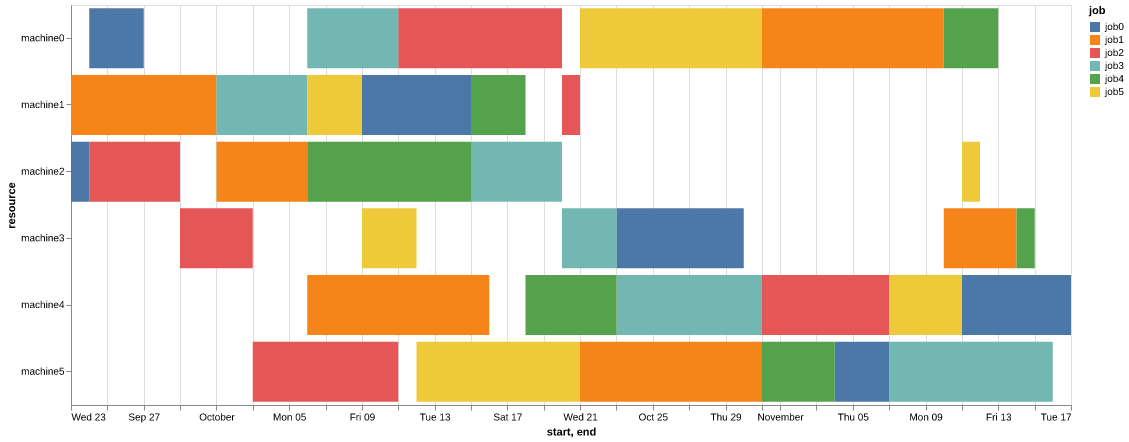

In [ ]:
mo.ui.altair_chart(plot_altair(model1_cpsat.to_df()))

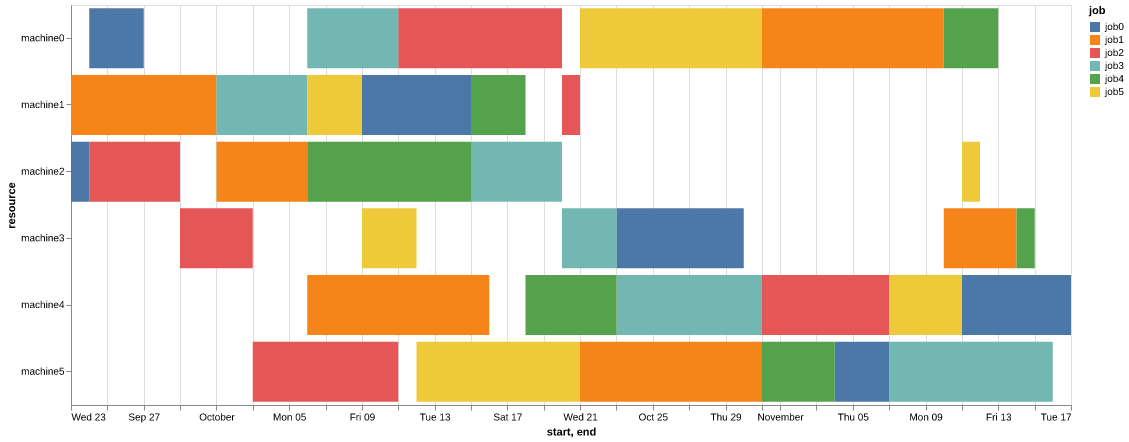

In [ ]:
plot_altair(model1_cpsat.to_df())

## 数理最適化ソルバーによる求解

HiGHS で離接定式化を解くのは `jobshop_highs.py` に分離.

OR-Tools と highspy はどっちも HiGHS を `libhighs.so.1` という同じ名前で同梱していて,
同じプロセスで両方 import すると後から読んだ方がバージョン違いの HiGHS を掴んで `ImportError` になる.
(ortools 9.15.6755 の中身は HiGHS 1.12.0, highspy 1.15.1 は HiGHS 1.15.1)

## FIXSTARS Amplify Scheduling Engine による求解

In [ ]:
dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True))
token = os.environ["FIXSTARS_SE"]


class ModelAmplifySe:
    def __init__(self, jobs: list[Job]):
        self.jobs = jobs
        num_machines = len(
            set(task.machine for job in self.jobs for task in job.tasks)
        )
        self.machines = list(range(num_machines))
        self.se_machines = [
            amplify_sched.Machine(name=f"machine{midx}")
            for midx in self.machines
        ]

        self.model = amplify_sched.Model()

        for semachine in self.se_machines:
            self.model.machines.add(machine=semachine)

        self.se_jobs = [
            amplify_sched.Job(name=f"job{jidx}")
            for jidx, _ in enumerate(self.jobs)
        ]
        for idx, job in enumerate(self.jobs):
            sejob = self.se_jobs[idx]
            self.model.jobs.add(sejob)
            for jdx, task in enumerate(job.tasks):
                semachine = self.se_machines[task.machine]
                setask = amplify_sched.Task()
                setask.processing_times[semachine] = task.time
                self.model.jobs[sejob.name].append(setask)

    def solve(self, timeout: int = 5) -> None:
        self.solution = self.model.solve(token=token, timeout=timeout)

    def get_makespan(self) -> int:
        return int(self.solution.table["Finish"].max())

    def to_df(self) -> pandas.DataFrame:
        sol_df = self.solution.table
        today = datetime.date.today()
        l = []
        for id_job, job in enumerate(self.jobs):
            sejob = self.se_jobs[id_job]
            for id_task, task in enumerate(job.tasks):
                start = int(
                    sol_df[sol_df["Job"] == sejob.name]["Start"].reset_index(
                        drop=True
                    )[id_task]
                )
                end = start + self.jobs[id_job].tasks[id_task].time
                l.append(
                    dict(
                        job=f"job{id_job}",
                        task=f"task{id_task}",
                        resource=f"machine{self.jobs[id_job].tasks[id_task].machine}",
                        start=today + datetime.timedelta(start),
                        end=today + datetime.timedelta(end),
                    )
                )
        df = pandas.DataFrame(l)
        df["start"] = pandas.to_datetime(df["start"])
        df["end"] = pandas.to_datetime(df["end"])
        return df

In [ ]:
model1_amplify = ModelAmplifySe(jobs1)
model1_amplify.solve()

print(f"makespan = {model1_amplify.get_makespan()}")

makespan = 55


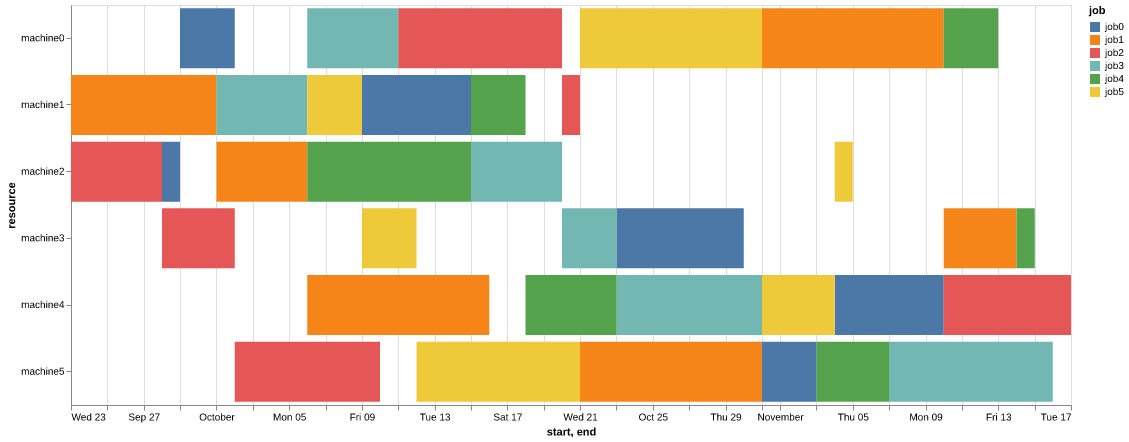

In [ ]:
plot_altair(model1_amplify.to_df())

## より大きい問題

In [ ]:
def gen_data(n_jobs: int, n_machines: int) -> list[Job]:
    random.seed(0)
    jobs = []
    for id_job in range(n_jobs):
        machines = list(range(n_machines))
        random.shuffle(machines)
        tasks = []
        for id_task in range(n_machines):
            machine = machines[id_task]
            time = random.randint(1, 10)
            tasks.append(Task(machine=machine, time=time))

        jobs.append(Job(tasks=tasks))

    return jobs

In [ ]:
jobs2 = gen_data(45, 15)
pprint(jobs2)

[Job(tasks=[Task(machine=1, time=9), Task(machine=10, time=3), Task(machine=9, time=5), Task(machine=5, time=3), Task(machine=11, time=2), Task(machine=2, time=10), Task(machine=3, time=5), Task(machine=7, time=9), Task(machine=8, time=10), Task(machine=4, time=3), Task(machine=0, time=5), Task(machine=14, time=2), Task(machine=12, time=2), Task(machine=6, time=6), Task(machine=13, time=8)]),
 Job(tasks=[Task(machine=13, time=2), Task(machine=11, time=7), Task(machine=10, time=1), Task(machine=0, time=10), Task(machine=2, time=8), Task(machine=4, time=6), Task(machine=14, time=4), Task(machine=7, time=6), Task(machine=3, time=2), Task(machine=9, time=4), Task(machine=12, time=10), Task(machine=6, time=4), Task(machine=5, time=4), Task(machine=1, time=3), Task(machine=8, time=9)]),
 Job(tasks=[Task(machine=10, time=10), Task(machine=6, time=9), Task(machine=3, time=10), Task(machine=11, time=5), Task(machine=0, time=8), Task(machine=2, time=2), Task(machine=9, time=10), Task(machine=4, 

In [ ]:
model2_cpsat = ModelCpSat(jobs2)
model2_cpsat.solve()


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 10 log_search_progress: true
Setting number of workers to 12

Initial optimization model '': (model_fingerprint: 0x62b4a1d48ce14446)
#Variables: 676 (#ints: 1 in objective) (675 primary variables)
  - 676 in [0,3683]
#kInterval: 675
#kLinMax: 1 (#expressions: 45)
#kLinear2: 630
#kNoOverlap: 15 (#intervals: 675)

Starting presolve at 0.00s
  1.25e-04s  0.00e+00d  [DetectDominanceRelations] 
  9.32e-03s  0.00e+00d  [PresolveToFixPoint] #num_loops=16 #num_dual_strengthening=1 
  5.09e-06s  0.00e+00d  [ExtractEncodingFromLinear] 
  1.89e-05s  0.00e+00d  [DetectDuplicateColumns] 
  1.48e-04s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 2'672 nodes and 3'331 arcs.
[Symmetry] Symmetry computation done. time: 0.000294719 dtime: 0.00031934
  1.49e-04s  0.00e+00d  [DetectDuplicateConstraintsWithDifferentEnforcements] 
  1.18e-03s  3.92e-06d  [Probe] #new_bounds=1 
  3.67e-06s  0.00e+00d  [MaxClique

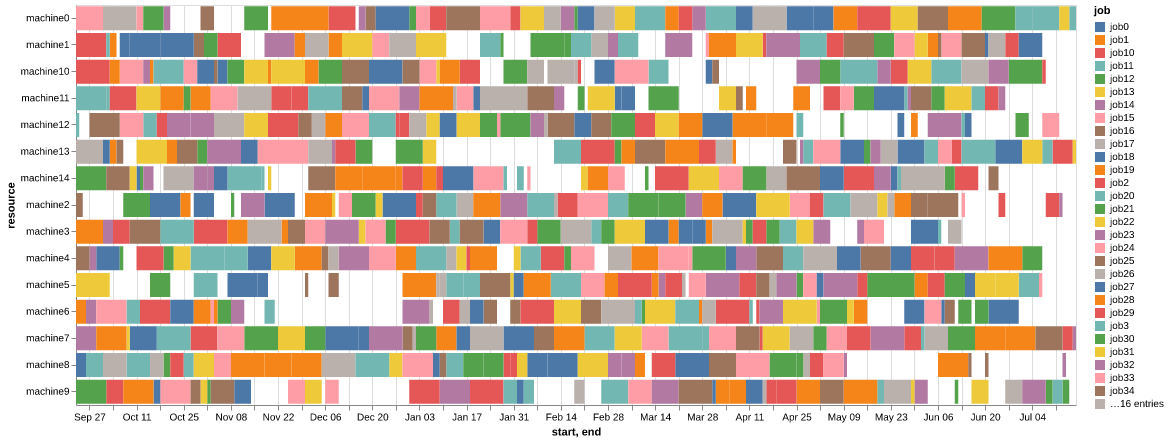

In [ ]:
plot_altair(model2_cpsat.to_df())

In [ ]:
model2_amplify = ModelAmplifySe(jobs2)
model2_amplify.solve(timeout=5)

print(f"makespan = {model2_amplify.get_makespan()}")

makespan = 297


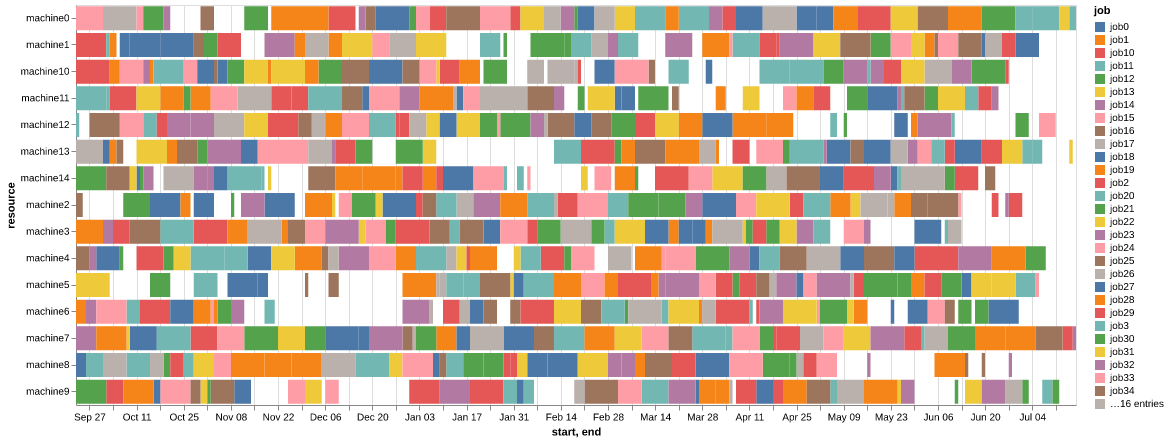

In [ ]:
plot_altair(model2_amplify.to_df())

## 他のインスタンス

ta50 は最適解は知られていない.

bounds

- upper: 1923
- lower: 1833

In [ ]:
instance_dir = os.path.join(parent, "jsplib/instances")

In [ ]:
fname3 = os.path.join(instance_dir, "ta50")
jobs3 = Job.from_file(fname3)

n=30, m=20


In [ ]:
model3_amplify = ModelAmplifySe(jobs3)
model3_amplify.solve(timeout=10)

mo.md(f"makespan = {model3_amplify.get_makespan()}")

makespan = 2099

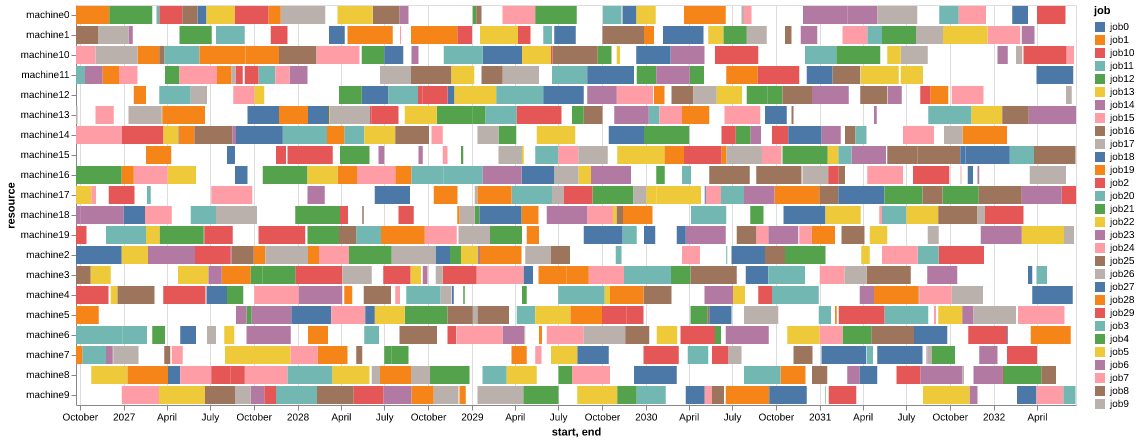

In [ ]:
plot_altair(model3_amplify.to_df())

In [ ]:
model3_cpsat = ModelCpSat(jobs3)
model3_cpsat.solve(timeout=10)

mo.md(f"makespan = {round(model3_cpsat.solver.objective_value)}")


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 10 log_search_progress: true
Setting number of workers to 12

Initial optimization model '': (model_fingerprint: 0x33f82f20921558d4)
#Variables: 601 (#ints: 1 in objective) (600 primary variables)
  - 601 in [0,30657]
#kInterval: 600
#kLinMax: 1 (#expressions: 30)
#kLinear2: 570
#kNoOverlap: 20 (#intervals: 600)

Starting presolve at 0.00s
  1.02e-04s  0.00e+00d  [DetectDominanceRelations] 
  1.04e-02s  0.00e+00d  [PresolveToFixPoint] #num_loops=21 #num_dual_strengthening=1 
  4.65e-06s  0.00e+00d  [ExtractEncodingFromLinear] 
  1.72e-05s  0.00e+00d  [DetectDuplicateColumns] 
  1.33e-04s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 2'392 nodes and 2'971 arcs.
[Symmetry] Symmetry computation done. time: 0.000124716 dtime: 0.0002559
  1.34e-04s  0.00e+00d  [DetectDuplicateConstraintsWithDifferentEnforcements] 
  9.03e-04s  4.02e-06d  [Probe] #new_bounds=1 
  3.62e-06s  0.00e+00d  [MaxClique

makespan = 2119

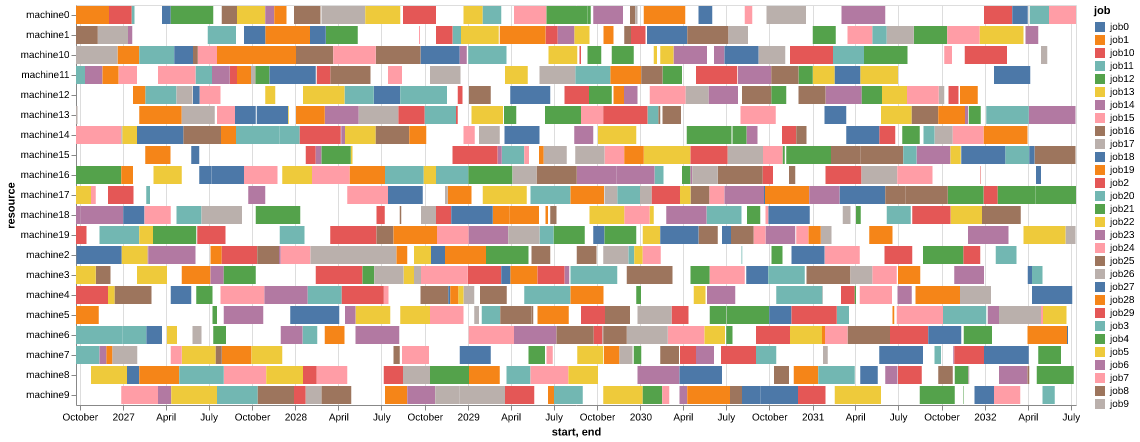

In [ ]:
plot_altair(model3_cpsat.to_df())

## didp での求解

### 状態

- $\text{Q}$: set 変数. 配置されていないタスクの集合を表す.
- $\text{tm}_m \space (\forall m: \text{machine})$: 機械ごとに makespan を保持する.
- $\text{tj}_j \space (\forall j: \text{job})$: ジョブごとに makespan を保持する.

### 目的関数

- $\text{makespan} := \max \{ \text{tm}_m, \text{tj}_j \mid m: \text{machine}, \space j: \text{job} \}$

### 更新規則

- タスク $\text{task} \in Q$ は全ての先行タスクが $Q$ に属していない時配置可能.
- $\text{task}$ が配置された場合, それを $Q$ から取り除く.
- $\text{task}$ が配置された場合, タスクを処理する機械 $m$ とタスクの属するジョブ $j$ に対して以下のように更新する.
    - $\text{tm}_m \leftarrow \max(\text{tm}_m + t_\text{task}, \space \text{tj}_j + t_\text{task})$
    - $\text{tj}_j \leftarrow \max(\text{tm}_m + t_\text{task}, \space \text{tj}_j + t_\text{task})$
- 上記更新の後, 目的関数を再計算する.

In [ ]:
class ModelDidp:
    def __init__(self, jobs: list[Job]):
        self.jobs = jobs
        n_tasks = sum(len(job.tasks) for job in self.jobs)
        n_machines = len(
            set(task.machine for job in self.jobs for task in job.tasks)
        )

        self.model = didppy.Model()

        objtype_task = self.model.add_object_type(number=n_tasks)

        remaining = self.model.add_set_var(
            object_type=objtype_task, target=list(range(n_tasks))
        )

        cur_time_per_machine = [
            # self.model.add_int_var(target=0) for _ in range(n_machines)
            self.model.add_int_resource_var(target=0, less_is_better=True)
            for _ in range(n_machines)
        ]
        cur_time_per_job = [
            # self.model.add_int_var(target=0) for _ in self.jobs
            self.model.add_int_resource_var(target=0, less_is_better=True)
            for _ in self.jobs
        ]

        self.model.add_base_case([remaining.is_empty()])

        # task_to_time = self.model.add_int_table(
        #     [task.time for job in self.jobs for task in job.tasks]
        # )
        # task_to_machine = self.model.add_int_table(
        #     [task.machine for job in self.jobs for task in job.tasks]
        # )

        precs = []
        id_jobtask = 0
        for id_job, job in enumerate(self.jobs):
            prec = set()
            for id_task, task in enumerate(job.tasks):
                precs.append(prec.copy())
                prec.add(id_jobtask)
                id_jobtask += 1

        task_to_prec = self.model.add_set_table(
            precs, object_type=objtype_task
        )

        id_jobtask = 0
        for id_job, job in enumerate(self.jobs):
            for id_task, task in enumerate(job.tasks):
                sched = didppy.Transition(
                    name=f"sched_job{id_job}_task{id_task}",
                    cost=(
                        didppy.max(
                            didppy.IntExpr.state_cost(),
                            didppy.max(
                                cur_time_per_machine[task.machine] + task.time,
                                cur_time_per_job[id_job] + task.time,
                            ),
                        )
                    ),
                    effects=[
                        (remaining, remaining.remove(id_jobtask)),
                        (
                            cur_time_per_job[id_job],
                            didppy.max(
                                cur_time_per_machine[task.machine] + task.time,
                                cur_time_per_job[id_job] + task.time,
                            ),
                        ),
                        (
                            cur_time_per_machine[task.machine],
                            didppy.max(
                                cur_time_per_machine[task.machine] + task.time,
                                cur_time_per_job[id_job] + task.time,
                            ),
                        ),
                    ],
                    preconditions=[
                        remaining.contains(id_jobtask),
                        remaining.isdisjoint(task_to_prec[id_jobtask]),
                    ],
                )
                self.model.add_transition(sched)

                id_jobtask += 1

        # 双対限界: 機械の空き時刻 + その機械に残っているタスクの処理時間の合計
        for id_machine in range(n_machines):
            machine_time = self.model.add_int_table(
                [
                    task.time if task.machine == id_machine else 0
                    for job in self.jobs
                    for task in job.tasks
                ]
            )
            self.model.add_dual_bound(
                remaining.is_empty().if_then_else(
                    0,
                    cur_time_per_machine[id_machine] + machine_time[remaining],
                )
            )

        # 双対限界: ジョブの空き時刻 + そのジョブに残っているタスクの処理時間の合計
        for id_job in range(len(self.jobs)):
            job_time = self.model.add_int_table(
                [
                    task.time if jdx == id_job else 0
                    for jdx, job in enumerate(self.jobs)
                    for task in job.tasks
                ]
            )
            self.model.add_dual_bound(
                remaining.is_empty().if_then_else(
                    0, cur_time_per_job[id_job] + job_time[remaining]
                )
            )

    def solve(self, timeout=10, threads: int = 8) -> None:
        self.solver = didppy.CABS(
            self.model,
            threads=threads,
            quiet=False,
            time_limit=timeout,
            f_operator=didppy.FOperator.Max,
        )
        # self.solver = didppy.LNBS(
        #     self.model, threads=threads, quiet=False, time_limit=timeout
        # )
        self.solution: didppy.Solution = self.solver.search()

In [ ]:
model1_didp = ModelDidp(jobs1)
model1_didp.solve(threads=10, timeout=10)

mo.md(f"makespan = {round(model1_didp.solution.cost)}")

Solver: CABS from DIDPPy v0.11.1
Searched with beam size: 1, threads: 10, kept: 157, sent: 0
Searched with beam size: 1, expanded: 36, elapsed time: 0.000373629
New primal bound: 96, expanded: 36, elapsed time: 0.000379651
Searched with beam size: 2, threads: 10, kept: 165, sent: 149
Searched with beam size: 2, expanded: 104, elapsed time: 0.000753481
New dual bound: 47, expanded: 104, elapsed time: 0.000755324
New primal bound: 86, expanded: 104, elapsed time: 0.000770403
Searched with beam size: 4, threads: 10, kept: 159, sent: 458
Searched with beam size: 4, expanded: 230, elapsed time: 0.001214145
New primal bound: 80, expanded: 230, elapsed time: 0.001239193
Searched with beam size: 8, threads: 10, kept: 189, sent: 1066
Searched with beam size: 8, expanded: 479, elapsed time: 0.001967605
New primal bound: 79, expanded: 479, elapsed time: 0.001984046
Searched with beam size: 16, threads: 10, kept: 248, sent: 2134
Searched with beam size: 16, expanded: 947, elapsed time: 0.003044047

makespan = 55

In [ ]:
model1_didp.solution.is_optimal

True

In [ ]:
for _t in model1_didp.solution.transitions:
    print(_t.name)

sched_job2_task0
sched_job0_task0
sched_job1_task0
sched_job3_task0
sched_job5_task0
sched_job0_task1
sched_job2_task1
sched_job1_task1
sched_job5_task1
sched_job4_task0
sched_job0_task2
sched_job3_task1
sched_job2_task2
sched_job1_task2
sched_job3_task2
sched_job3_task3
sched_job5_task2
sched_job1_task3
sched_job4_task1
sched_job4_task2
sched_job2_task3
sched_job3_task4
sched_job0_task3
sched_job0_task4
sched_job2_task4
sched_job5_task3
sched_job1_task4
sched_job5_task4
sched_job0_task5
sched_job5_task5
sched_job1_task5
sched_job4_task3
sched_job3_task5
sched_job2_task5
sched_job4_task4
sched_job4_task5


In [ ]:
model2_didp = ModelDidp(jobs2)
model2_didp.solve(threads=10, timeout=10)

mo.md(f"makespan = {round(model2_didp.solution.cost)}")

Solver: CABS from DIDPPy v0.11.1
Searched with beam size: 1, threads: 10, kept: 26182, sent: 0
Searched with beam size: 1, expanded: 675, elapsed time: 0.643099341
New primal bound: 500, expanded: 675, elapsed time: 0.643101786
Searched with beam size: 2, threads: 10, kept: 26303, sent: 26272
Searched with beam size: 2, expanded: 2014, elapsed time: 1.292227595
New dual bound: 297, expanded: 2014, elapsed time: 1.292229729
New primal bound: 458, expanded: 2014, elapsed time: 1.293050296
Searched with beam size: 4, threads: 10, kept: 25804, sent: 77372
Searched with beam size: 4, expanded: 4696, elapsed time: 1.9742528240000001
New primal bound: 455, expanded: 4696, elapsed time: 1.9750531630000001
Searched with beam size: 8, threads: 10, kept: 25776, sent: 181614
Searched with beam size: 8, expanded: 10033, elapsed time: 3.279867192
New primal bound: 431, expanded: 10033, elapsed time: 3.28055139
Searched with beam size: 16, threads: 10, kept: 39185, sent: 353722
Searched with beam siz

makespan = 415

In [ ]:
model3_didp = ModelDidp(jobs3)
model3_didp.solve(threads=10, timeout=10)

mo.md(f"makespan = {round(model3_didp.solution.cost)}")

Solver: CABS from DIDPPy v0.11.1
Searched with beam size: 1, threads: 10, kept: 15680, sent: 0
Searched with beam size: 1, expanded: 600, elapsed time: 0.291431668
New primal bound: 4254, expanded: 600, elapsed time: 0.291434824
Searched with beam size: 2, threads: 10, kept: 15668, sent: 15727
Searched with beam size: 2, expanded: 1784, elapsed time: 0.60064597
New dual bound: 1674, expanded: 1784, elapsed time: 0.600648545
New primal bound: 4155, expanded: 1784, elapsed time: 0.601443243
Searched with beam size: 4, threads: 10, kept: 15973, sent: 47186
Searched with beam size: 4, expanded: 4091, elapsed time: 0.918362157
Searched with beam size: 8, threads: 10, kept: 15599, sent: 109626
Searched with beam size: 8, expanded: 8808, elapsed time: 1.528777367
New primal bound: 3646, expanded: 8808, elapsed time: 1.5294890570000002
Searched with beam size: 16, threads: 10, kept: 25202, sent: 226444
Searched with beam size: 16, expanded: 18286, elapsed time: 2.749276367
New primal bound: 35

makespan = 3284

## 離接定式化のグラフによる表示

JSP は タスクをノード, 依存関係や同時処理禁止規則をエッジで表現したグラフからエッジを選択する問題として表現することができる.

### 参考

- https://acrogenesis.com/or-tools/documentation/user_manual/manual/ls/jobshop_def_data.html
- https://zenn.dev/fusic/articles/0fed6d5dfbdeb5

### 定数

- $J$: ジョブの集合
- $M$: マシンの集合
- $O$: オペレーションの集合
- $O_j$: ジョブ $j$ のオペレーションの集合
- $O_m$: マシン $m$ で処理するオペレーションの集合
- $t_o$: オペレーション $o$ の処理時間

### グラフ

- ノード $N := O \cup \{ \text{source}, \text{target} \}$
- エッジ $E := E^c \cup E^d$
    - Conjunctive Edges $E^c$: オペレーション $o$ と $o'$ が同じジョブに属しており, $o$ の後に $o'$ を処理しなければならない場合, $(o, o') \in E^c$.
      また, $o$ があるジョブの最初のオペレーションであるとき $(\text{source}, o) \in E^c$.
      $o$ があるジョブの最後のオペレーションであるとき $(o, \text{target}) \in E^c$.
    - Disjunctive Edges $E^d$: オペレーション $o$ と $o'$ が同じマシンで処理されるとき, $(o, o') \in E^d$ かつ $(o', o) \in E^d$.
      このエッジは双方向のうちどちらかを選択し, 選択されたエッジによりオペレーションの処理順序が定まる.

このグラフのエッジで繋がれたノード(オペレーション)の間には処理順序の関係がある.
Conjunctive edge は同一ジョブ内オペレーションの順序関係を表し,
Disjunctive edge は同一マシンで処理するオペレーションの間の順序関係を表す.

### 決定変数

- $x_e \in \{ 0, 1 \} \space (e \in E)$: エッジ $e$ を選択する場合のみ $1$.
- $s_n \in \mathbb{Z} \space (n \in N)$: オペレーションの開始時刻. $\text{source}$ ノードの開始時刻は 0, 処理時間も 0 とする.

### 制約条件

- $e = (u, v)$ とする. このとき $x_e = 1 \Rightarrow s_u + t_u \leq s_v$
    - $e \in E^c \Rightarrow x_e = 1$
    - $(u, v) \in E^d \Rightarrow x_{(u,v)} + x_{(v,u)} = 1$

### 目的関数

- $s_\text{target}$ が makespan を表す. これを最小化する.

## 巡回路制約を用いた実装

上記のグラフにマシン自体をノードとして足し,
disjunctive edge のみを辿ってマシンごとに順回路を作成することでマシン内での実行順を記述することができる.

In [ ]:
class ModelCpSatArc:
    def __init__(self, jobs: list[Job]):
        machines = sorted(
            list(set(task.machine for job in jobs for task in job.tasks))
        )

        # タスクに 0 から番号を割り振る.
        # source と target はそれぞれ -1, -2 とする.
        task_indices = []
        idx = 0
        for job in jobs:
            indices = []
            for task in job.tasks:
                indices.append(idx)
                idx += 1
            task_indices.append(indices)

        all_tasks = [task for job in jobs for task in job.tasks]

        horizon = sum(task.time for job in jobs for task in job.tasks)

        model = cp_model.CpModel()

        edges = {}
        starts = {}

        # start time
        starts[-1] = model.new_constant(0)
        starts[-2] = model.new_int_var(0, horizon, "")
        for indices in task_indices:
            for idx in indices:
                starts[idx] = model.new_int_var(0, horizon, "")

        # Conjunctive Edges
        for indices in task_indices:
            edges[(-1, indices[0])] = model.new_constant(1)
            edges[(indices[-1], -2)] = model.new_constant(1)
            for i, _ in enumerate(indices):
                if i == 0:
                    continue
                edges[(indices[i - 1], indices[i])] = model.new_constant(1)

        # Disjunctive Edges
        for m in machines:
            indices_m = [
                idx
                for indices, job in zip(task_indices, jobs)
                for idx, task in zip(indices, job.tasks)
                if task.machine == m
            ] + [-3 - m]

            edges_m = {
                (u, v): model.new_bool_var("")
                for u in indices_m
                for v in indices_m
                if u != v
            }
            model.add_circuit((u, v, var) for (u, v), var in edges_m.items())

            edges |= edges_m

        for (u, v), var in edges.items():
            if u < -2 or v < -2:
                continue

            if u == -1:
                model.add(starts[u] <= starts[v])
            else:
                model.add(
                    starts[u] + all_tasks[u].time <= starts[v]
                ).only_enforce_if(edges[(u, v)])

        model.minimize(starts[-2])

        self.model = model
        self.objective = starts[-2]

    def solve(self, timeout: int = 10):
        self.solver = cp_model.CpSolver()
        self.solver.parameters.log_search_progress = True
        self.solver.parameters.max_time_in_seconds = timeout
        self.status = self.solver.solve(self.model)

In [ ]:
model1_cpsatarc = ModelCpSatArc(jobs1)
model1_cpsatarc.solve()

mo.md(f"makespan = {round(model1_cpsatarc.solver.objective_value)}")


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 10 log_search_progress: true
Setting number of workers to 12

Initial optimization model '': (model_fingerprint: 0xaacdc7c50f505cd1)
#Variables: 291 (#ints: 1 in objective) (291 primary variables)
  - 252 Booleans in [0,1]
  - 37 in [0,197]
  - 2 constants in {0,1} 
#kCircuit: 6
#kLinear2: 222 (#enforced: 216)

Starting presolve at 0.00s
  6.34e-05s  0.00e+00d  [DetectDominanceRelations] 
  2.10e-03s  1.20e-07d  [PresolveToFixPoint] #num_loops=6 #num_dual_strengthening=1 
  1.62e-06s  0.00e+00d  [ExtractEncodingFromLinear] 
  1.05e-05s  0.00e+00d  [DetectDuplicateColumns] 
  2.09e-05s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 836 nodes and 1'403 arcs.
[Symmetry] Symmetry computation done. time: 0.000119938 dtime: 0.00010138
  1.41e-05s  0.00e+00d  [DetectDuplicateConstraintsWithDifferentEnforcements] 
  1.40e-03s  5.98e-04d  [Probe] #probed=504 #new_binary_clauses=126 
  2.02e-06s  0.0

makespan = 55

In [ ]:
model3_cpsatarc = ModelCpSatArc(jobs3)
model3_cpsatarc.solve(timeout=10)

mo.md(f"makespan = {round(model3_cpsatarc.solver.objective_value)}")


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 10 log_search_progress: true
Setting number of workers to 12

Initial optimization model '': (model_fingerprint: 0x50689656cfb32057)
#Variables: 19'203 (#ints: 1 in objective) (19'203 primary variables)
  - 18'600 Booleans in [0,1]
  - 601 in [0,30657]
  - 2 constants in {0,1} 
#kCircuit: 20
#kLinear2: 18'030 (#enforced: 18'000)

Starting presolve at 0.00s
  3.36e-03s  0.00e+00d  [DetectDominanceRelations] 
  3.46e-01s  4.00e-07d  [PresolveToFixPoint] #num_loops=20 #num_dual_strengthening=1 
  7.90e-05s  0.00e+00d  [ExtractEncodingFromLinear] 
  7.21e-04s  0.00e+00d  [DetectDuplicateColumns] 
  4.96e-04s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 57'022 nodes and 109'799 arcs.
[Symmetry] Symmetry computation done. time: 0.00563565 dtime: 0.00701877
  6.65e-04s  0.00e+00d  [DetectDuplicateConstraintsWithDifferentEnforcements] 
  3.45e-01s  1.82e-01d  [Probe] #probed=37'200 #new_binary_cl

makespan = 24254

なんか全然ダメだった...

区間変数より circuit constraint の方がいい場合もあるらしい[^1]が, 今回はダメそう.

[^1]: https://d-krupke.github.io/cpsat-primer/04B_advanced_modelling.html